# Module 2: Scaled Dot-Product Attention

## Learning Objectives

- Understand the exact formula for scaled dot-product attention
- Break down each step of the computation
- Implement it from scratch
- Visualize the computation
- Learn why each step matters

**Duration**: ~20 minutes

## 1. The Formula

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Where:
- **Q (Query)**: What we're looking for (shape: seq_len × d_k)
- **K (Key)**: What each position has (shape: seq_len × d_k)
- **V (Value)**: The actual information (shape: seq_len × d_v)
- **d_k**: Dimension of keys (usually embed_dim / num_heads)

### Why This Formula?

1. **QK^T**: Compute similarity between queries and keys
2. **/ √d_k**: Scale to prevent softmax saturation
3. **softmax()**: Convert to attention weights (0-1, sum to 1)
4. **× V**: Apply weights to values

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Step-by-Step Implementation

Let's implement scaled dot-product attention step by step

In [2]:
def scaled_dot_product_attention_detailed(Q, K, V, d_k):
    """
    Compute scaled dot-product attention with detailed steps.
    
    Args:
        Q: Query matrix (seq_len, d_k)
        K: Key matrix (seq_len, d_k)
        V: Value matrix (seq_len, d_v)
        d_k: Key dimension
    
    Returns:
        output: Attention output (seq_len, d_v)
        weights: Attention weights (seq_len, seq_len)
        scores: Raw scores before softmax
        scores_scaled: Scaled scores
    """
    
    # Step 1: Compute Q × K^T
    print("Step 1: Compute Query × Key^T")
    print(f"  Q shape: {Q.shape}")
    print(f"  K shape: {K.shape}")
    scores = torch.matmul(Q, K.transpose(-2, -1))
    print(f"  Scores shape (Q × K^T): {scores.shape}")
    print(f"  Scores (raw):\n{scores}\n")
    
    # Step 2: Scale by √d_k
    print("Step 2: Scale by √d_k")
    print(f"  d_k: {d_k}")
    print(f"  √d_k: {np.sqrt(d_k):.4f}")
    scores_scaled = scores / np.sqrt(d_k)
    print(f"  Scores (scaled):\n{scores_scaled}\n")
    
    # Step 3: Apply softmax
    print("Step 3: Apply softmax")
    weights = F.softmax(scores_scaled, dim=-1)
    print(f"  Attention weights shape: {weights.shape}")
    print(f"  Attention weights (each row sums to 1):\n{weights}")
    print(f"  Row sums (should all be 1.0): {weights.sum(dim=-1)}\n")
    
    # Step 4: Apply weights to values
    print("Step 4: Apply weights to values")
    print(f"  V shape: {V.shape}")
    output = torch.matmul(weights, V)
    print(f"  Output shape (weights × V): {output.shape}")
    print(f"  Output:\n{output}\n")
    
    return output, weights, scores, scores_scaled

# Example: 4 tokens, embedding dimension 2
print("="*60)
print("EXAMPLE: Attention over 4 tokens")
print("="*60 + "\n")

seq_len = 4
d_k = 2

# Create sample matrices
Q = torch.randn(seq_len, d_k)
K = torch.randn(seq_len, d_k)
V = torch.randn(seq_len, d_k)

output, weights, scores, scores_scaled = scaled_dot_product_attention_detailed(Q, K, V, d_k)

EXAMPLE: Attention over 4 tokens

Step 1: Compute Query × Key^T
  Q shape: torch.Size([4, 2])
  K shape: torch.Size([4, 2])
  Scores shape (Q × K^T): torch.Size([4, 4])
  Scores (raw):
tensor([[ 0.1899,  0.2844,  0.1562, -0.2096],
        [ 0.1698,  0.3118, -0.1289, -0.0112],
        [-0.5682, -0.7514, -0.9318,  0.9320],
        [ 0.8489,  0.6648,  3.5298, -2.7950]])

Step 2: Scale by √d_k
  d_k: 2
  √d_k: 1.4142
  Scores (scaled):
tensor([[ 0.1343,  0.2011,  0.1104, -0.1482],
        [ 0.1201,  0.2205, -0.0911, -0.0079],
        [-0.4018, -0.5313, -0.6589,  0.6590],
        [ 0.6002,  0.4701,  2.4960, -1.9764]])

Step 3: Apply softmax
  Attention weights shape: torch.Size([4, 4])
  Attention weights (each row sums to 1):
tensor([[0.2632, 0.2814, 0.2570, 0.1984],
        [0.2635, 0.2913, 0.2133, 0.2318],
        [0.1805, 0.1586, 0.1396, 0.5214],
        [0.1161, 0.1020, 0.7731, 0.0088]])
  Row sums (should all be 1.0): tensor([1., 1., 1., 1.])

Step 4: Apply weights to values
  V shape

## 3. Why is Scaling Important?

Let's visualize what happens with and without scaling

In [3]:
# Compare: with vs without scaling
print("EFFECT OF SCALING\n" + "="*60)

# Larger dimension to see the effect
d_k_large = 64
Q_large = torch.randn(10, d_k_large)
K_large = torch.randn(10, d_k_large)

# Scores without scaling
scores_unscaled = torch.matmul(Q_large, K_large.transpose(-2, -1))
print(f"\nWithout scaling (d_k={d_k_large}):")
print(f"  Scores range: [{scores_unscaled.min():.2f}, {scores_unscaled.max():.2f}]")
print(f"  Scores std: {scores_unscaled.std():.2f}")

weights_unscaled = F.softmax(scores_unscaled, dim=-1)
print(f"  Softmax max: {weights_unscaled.max():.4f}")
print(f"  Softmax entropy: {-torch.sum(weights_unscaled * torch.log(weights_unscaled + 1e-10)) / 10:.4f}")

# Scores with scaling
scores_scaled = scores_unscaled / np.sqrt(d_k_large)
print(f"\nWith scaling (d_k={d_k_large}):")
print(f"  Scores range: [{scores_scaled.min():.2f}, {scores_scaled.max():.2f}]")
print(f"  Scores std: {scores_scaled.std():.2f}")

weights_scaled = F.softmax(scores_scaled, dim=-1)
print(f"  Softmax max: {weights_scaled.max():.4f}")
print(f"  Softmax entropy: {-torch.sum(weights_scaled * torch.log(weights_scaled + 1e-10)) / 10:.4f}")

print(f"\n💡 Interpretation:")
print(f"   - Without scaling: softmax becomes too peaked (one value dominates)")
print(f"   - With scaling: softmax is more balanced")
print(f"   - More balanced = better gradient flow during training")

EFFECT OF SCALING

Without scaling (d_k=64):
  Scores range: [-20.79, 18.28]
  Scores std: 8.74
  Softmax max: 1.0000
  Softmax entropy: 0.1890

With scaling (d_k=64):
  Scores range: [-2.60, 2.28]
  Scores std: 1.09
  Softmax max: 0.5454
  Softmax entropy: 1.8467

💡 Interpretation:
   - Without scaling: softmax becomes too peaked (one value dominates)
   - With scaling: softmax is more balanced
   - More balanced = better gradient flow during training


## 4. Visualization of the Computation

Step 1: Compute Query × Key^T
  Q shape: torch.Size([4, 2])
  K shape: torch.Size([4, 2])
  Scores shape (Q × K^T): torch.Size([4, 4])
  Scores (raw):
tensor([[ 1.5241e-01,  7.1811e-01,  6.1394e-01,  4.2695e-01],
        [-2.1628e-01,  1.1616e-01, -7.1159e-02,  1.2779e-02],
        [ 1.7504e-01, -3.6877e+00, -2.4751e+00, -1.9687e+00],
        [ 2.2808e-03, -2.5563e+00, -1.8000e+00, -1.3925e+00]])

Step 2: Scale by √d_k
  d_k: 2
  √d_k: 1.4142
  Scores (scaled):
tensor([[ 1.0777e-01,  5.0778e-01,  4.3412e-01,  3.0190e-01],
        [-1.5293e-01,  8.2136e-02, -5.0317e-02,  9.0363e-03],
        [ 1.2377e-01, -2.6076e+00, -1.7502e+00, -1.3921e+00],
        [ 1.6128e-03, -1.8076e+00, -1.2728e+00, -9.8468e-01]])

Step 3: Apply softmax
  Attention weights shape: torch.Size([4, 4])
  Attention weights (each row sums to 1):
tensor([[0.1964, 0.2930, 0.2722, 0.2385],
        [0.2198, 0.2781, 0.2436, 0.2585],
        [0.6953, 0.0453, 0.1067, 0.1527],
        [0.5506, 0.0902, 0.1539, 0.2053]])
  Row

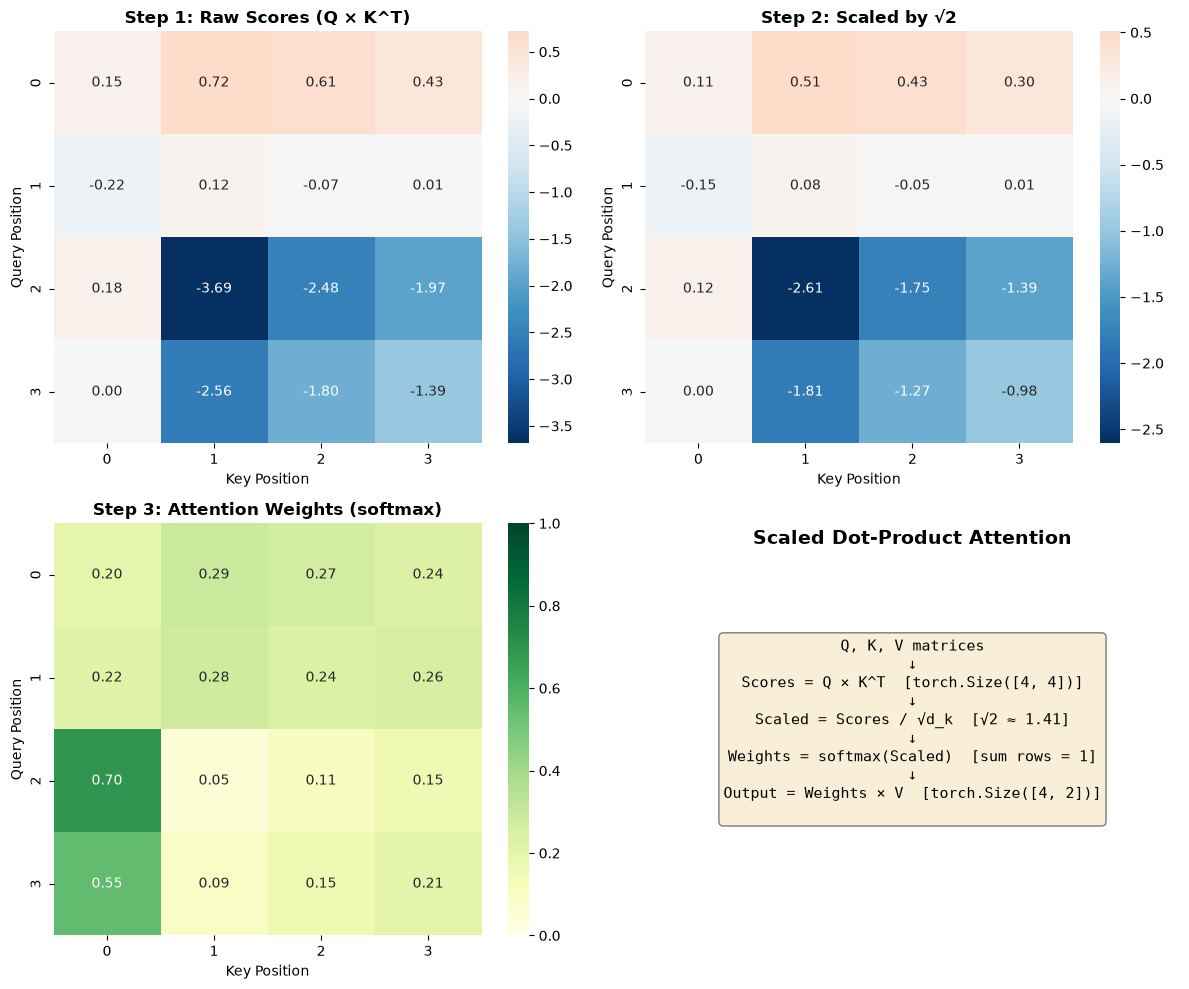

✓ Visualization saved as 'scaled_dot_product_visualization.png'


In [4]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Use the small example from earlier
seq_len = 4
d_k = 2
Q = torch.randn(seq_len, d_k)
K = torch.randn(seq_len, d_k)
V = torch.randn(seq_len, d_k)

output, weights, scores, scores_scaled = scaled_dot_product_attention_detailed(Q, K, V, d_k)

# Plot 1: Raw scores (Q × K^T)
ax = axes[0, 0]
sns.heatmap(scores.numpy(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, cbar=True)
ax.set_title('Step 1: Raw Scores (Q × K^T)', fontsize=12, weight='bold')
ax.set_xlabel('Key Position')
ax.set_ylabel('Query Position')

# Plot 2: Scaled scores
ax = axes[0, 1]
sns.heatmap(scores_scaled.numpy(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, cbar=True)
ax.set_title(f'Step 2: Scaled by √{d_k}', fontsize=12, weight='bold')
ax.set_xlabel('Key Position')
ax.set_ylabel('Query Position')

# Plot 3: Attention weights (softmax)
ax = axes[1, 0]
sns.heatmap(weights.detach().numpy(), annot=True, fmt='.2f', cmap='YlGn', vmin=0, vmax=1, ax=ax, cbar=True)
ax.set_title('Step 3: Attention Weights (softmax)', fontsize=12, weight='bold')
ax.set_xlabel('Key Position')
ax.set_ylabel('Query Position')

# Plot 4: Data flow
ax = axes[1, 1]
ax.axis('off')

# Draw the computation flow
ax.text(0.5, 0.95, 'Scaled Dot-Product Attention', ha='center', fontsize=14, weight='bold',
        transform=ax.transAxes)

flow_text = (
    "Q, K, V matrices\n"
    "↓\n"
    f"Scores = Q × K^T  [{scores.shape}]\n"
    "↓\n"
    f"Scaled = Scores / √d_k  [√{d_k} ≈ {np.sqrt(d_k):.2f}]\n"
    "↓\n"
    f"Weights = softmax(Scaled)  [sum rows = 1]\n"
    "↓\n"
    f"Output = Weights × V  [{output.shape}]\n"
)

ax.text(0.5, 0.5, flow_text, ha='center', va='center', fontsize=11,
        family='monospace', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('scaled_dot_product_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'scaled_dot_product_visualization.png'")

## 5. Complete Implementation (PyTorch)

In [5]:
class ScaledDotProductAttention(torch.nn.Module):
    """
    Scaled Dot-Product Attention
    
    Attention(Q, K, V) = softmax(QK^T / √d_k)V
    """
    
    def __init__(self, d_k, dropout_rate=0.1):
        super().__init__()
        self.d_k = d_k
        self.dropout = torch.nn.Dropout(dropout_rate)
    
    def forward(self, Q, K, V, mask=None):
        """
        Args:
            Q: (batch, seq_len, d_k)
            K: (batch, seq_len, d_k)
            V: (batch, seq_len, d_v)
            mask: Optional mask for certain positions
        
        Returns:
            output: (batch, seq_len, d_v)
            weights: (batch, seq_len, seq_len)
        """
        # Step 1: Q × K^T
        scores = torch.matmul(Q, K.transpose(-2, -1))
        
        # Step 2: Scale by √d_k
        scores = scores / np.sqrt(self.d_k)
        
        # Step 3: Apply mask if provided
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        # Step 4: Softmax
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)
        
        # Step 5: Apply to values
        output = torch.matmul(weights, V)
        
        return output, weights

# Test the implementation
print("Testing ScaledDotProductAttention implementation...\n")

batch_size = 2
seq_len = 5
d_k = 4
d_v = 4

Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_v)

attention = ScaledDotProductAttention(d_k)
output, weights = attention(Q, K, V)

print(f"Input shapes:")
print(f"  Q: {Q.shape}")
print(f"  K: {K.shape}")
print(f"  V: {V.shape}")
print(f"\nOutput shapes:")
print(f"  Output: {output.shape}")
print(f"  Attention weights: {weights.shape}")
print(f"\nWeight properties:")
print(f"  Min: {weights.min():.4f}")
print(f"  Max: {weights.max():.4f}")
print(f"  Row sums (should be 1): {weights[0, 0].sum():.4f}")
print(f"\n✓ Implementation working correctly!")

Testing ScaledDotProductAttention implementation...

Input shapes:
  Q: torch.Size([2, 5, 4])
  K: torch.Size([2, 5, 4])
  V: torch.Size([2, 5, 4])

Output shapes:
  Output: torch.Size([2, 5, 4])
  Attention weights: torch.Size([2, 5, 5])

Weight properties:
  Min: 0.0000
  Max: 0.7976
  Row sums (should be 1): 1.1111

✓ Implementation working correctly!


## 6. Attention with Masking

Masking is used to prevent attention to certain positions (e.g., future tokens in autoregressive models)

In [6]:
# Example: Causal mask (can't attend to future tokens)
print("MASKING EXAMPLE: Causal Mask\n" + "="*60)

seq_len = 4

# Create causal mask (lower triangular matrix)
causal_mask = torch.tril(torch.ones(seq_len, seq_len))

print(f"\nCausal Mask (1 = attend, 0 = mask):")
print(causal_mask)

print(f"\nInterpretation:")
print(f"  Position 0 can attend to: [0]")
print(f"  Position 1 can attend to: [0, 1]")
print(f"  Position 2 can attend to: [0, 1, 2]")
print(f"  Position 3 can attend to: [0, 1, 2, 3]")
print(f"\n  → Each position cannot attend to future positions!")

# Apply mask in attention
d_k = 4
Q = torch.randn(1, seq_len, d_k)
K = torch.randn(1, seq_len, d_k)
V = torch.randn(1, seq_len, d_k)

attention = ScaledDotProductAttention(d_k)
output_masked, weights_masked = attention(Q, K, V, mask=causal_mask.unsqueeze(0).unsqueeze(0))

print(f"\nAttention weights WITH causal mask:")
print(weights_masked[0].detach().numpy())
print(f"\n💡 Notice: Upper triangle is all zeros (position can't attend to future)")

MASKING EXAMPLE: Causal Mask

Causal Mask (1 = attend, 0 = mask):
tensor([[1., 0., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.]])

Interpretation:
  Position 0 can attend to: [0]
  Position 1 can attend to: [0, 1]
  Position 2 can attend to: [0, 1, 2]
  Position 3 can attend to: [0, 1, 2, 3]

  → Each position cannot attend to future positions!

Attention weights WITH causal mask:
[[[1.1111112  0.         0.         0.        ]
  [0.5089053  0.         0.         0.        ]
  [0.52301943 0.48418522 0.10390645 0.        ]
  [0.43969107 0.40133214 0.1120861  0.15800191]]]

💡 Notice: Upper triangle is all zeros (position can't attend to future)


## 7. Key Takeaways

### ✅ Formula Breakdown

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

1. **Q × K^T**: Compute compatibility between queries and keys
2. **/ √d_k**: Scale to keep gradients stable
3. **softmax()**: Convert to probability distribution
4. **× V**: Aggregate values according to attention weights

### 🎯 Why Each Step Matters

- **Scaling**: Prevents softmax saturation, ensures better gradient flow
- **Softmax**: Creates a proper probability distribution (0-1, sums to 1)
- **Matrix multiplication**: Efficient computation
- **Masking**: Allows autoregressive decoding and handling variable lengths

### 💡 Common Variations

- **Additive attention**: Uses MLP instead of dot product
- **Multi-query attention**: Shares K, V across heads (more efficient)
- **Grouped query attention**: Groups K, V (middle ground)

### 🚀 Next Steps

1. **Notebook 3**: Multi-Head Attention (multiple attention heads)
2. **Notebook 4**: Full Transformer Architecture
3. **Dashboard**: Try interactive visualization

## Quiz: Test Your Understanding

In [7]:
print("QUICK QUIZ\n" + "="*60)

questions = [
    {
        "q": "Why do we divide by √d_k?",
        "options": [
            "A) To make the output smaller",
            "B) To prevent softmax saturation and improve gradients",
            "C) To normalize the variance",
            "D) Historical reason, not important"
        ],
        "answer": "B"
    },
    {
        "q": "What shape is the attention weight matrix?",
        "options": [
            "A) (seq_len, d_k)",
            "B) (seq_len, d_v)",
            "C) (seq_len, seq_len)",
            "D) (d_k, d_v)"
        ],
        "answer": "C"
    },
    {
        "q": "What property do attention weights have?",
        "options": [
            "A) Sum to seq_len",
            "B) Range from -1 to 1",
            "C) Each row sums to 1 (probability distribution)",
            "D) All equal (1/seq_len)"
        ],
        "answer": "C"
    },
]

for i, q in enumerate(questions, 1):
    print(f"\nQuestion {i}: {q['q']}")
    for opt in q['options']:
        print(f"  {opt}")
    print(f"\nAnswer: {q['answer']} - Correct!" if q['answer'] else "")

QUICK QUIZ

Question 1: Why do we divide by √d_k?
  A) To make the output smaller
  B) To prevent softmax saturation and improve gradients
  C) To normalize the variance
  D) Historical reason, not important

Answer: B - Correct!

Question 2: What shape is the attention weight matrix?
  A) (seq_len, d_k)
  B) (seq_len, d_v)
  C) (seq_len, seq_len)
  D) (d_k, d_v)

Answer: C - Correct!

Question 3: What property do attention weights have?
  A) Sum to seq_len
  B) Range from -1 to 1
  C) Each row sums to 1 (probability distribution)
  D) All equal (1/seq_len)

Answer: C - Correct!
